# Data Visualization Fundamentals (Pandas, Plotly, Matplotlib, Seaborn)

Today, we are going to utilize Pandas to help with some real world analysis. Let's use a dataset concerning iris, one of the more popular ones.

This can be found in this link: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data

Let's first take a look at the head of the dataset to understand what we're working with. Make sure to import the dataset and pandas first.

In [2]:
import pandas as pd

dataset = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data')

dataset.head()

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


As we see, the dataset doesn't have headers for its columns. We can find them at this link.

https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.names

From the text file, what are the names of the columns? Let's add them.



In [3]:
dataframe_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

#TASK : Reassign Column Names
dataset.columns = dataframe_names

In [4]:
dataset.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [5]:
dataset["sepal_width"]

0      3.0
1      3.2
2      3.1
3      3.6
4      3.9
      ... 
144    3.0
145    2.5
146    3.0
147    3.4
148    3.0
Name: sepal_width, Length: 149, dtype: float64

In [6]:
#TASK: What are the classes of irises, and their respective counts in the dataset?
dataset["class"].value_counts()

class
Iris-versicolor    50
Iris-virginica     50
Iris-setosa        49
Name: count, dtype: int64

In [7]:
dataset.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [28]:
"""

Group the dataset by class, and find the quartile petal lengths for each class [0.25, 0.5, 0.75].
quantile([0.25, 0.5, 0.75])

"""
dataset.groupby("class")["petal_length"].quantile([0.25, 0.5, 0.75]).unstack()
# dataset.groupby("sepal_width").mean(numeric_only=True)


,0.25,0.50,0.75
class,,,
Iris-setosa,1.4,1.50,1.600
Iris-versicolor,4.0,4.35,4.600
Iris-virginica,5.1,5.55,5.875


In [9]:
import plotly.express as px

Plotly Express documentation: https://plotly.com/python-api-reference/plotly.express.html

A **histogram** is commonly used to graph frequency distributions. It is similar to a bar chart, but the height of each bar shows the frequency (count) within each range.

In [10]:
"""
Create a density histogram of sepal length for the flowers dataset
"""
px.histogram(dataset, title = "Histogram for Sepal Length", x = 'sepal_length')


In [11]:
"""
Create a probability histogram of sepal length for the flowers dataset

"""

px.histogram(dataset, x = 'sepal_length', histnorm = 'probability', title = 'probability histogram')

A **scatter plot** shows the relationship between two different numerical variables.
Each member of the dataset gets plotted as a Cartesian point (x, y) whose coordinates relate to its values for the two variables. If a scatter plot is coded, an additional variable can be displayed.

In [12]:
"""

Create a scatter plot of `sepal_length` and `sepal_width`, where the x-axis has
`sepal_length` and y-axis has `sepal_width`. Code the plot by class.

HINT: Use the function px.scatter

Then, do the same, but compare petal_length with petal_width.

"""


px.scatter(dataset, x = 'sepal_length', y = 'sepal_width', color = 'class')

A **box plot** depicts groups of numerical data through their quartiles. They can also have extending lines (whiskers) to form a **box-and-whisker plot** that not only depicts quartiles, but the minimum and maximum values before reaching outlier status (Q3/Q1 +/- 1.5*IQR).

In [13]:
"""

Create a boxplot of class vs petal_length.

HINT: Use the function px.box

"""

px.box(dataset, x='class', y='petal_length', color='class')


A **violin plot** is similar to a box plot, except it also shows the probability density of the data at different values.

In [14]:
"""

Create a violin plot of class vs petal_length

HINT: Use the function px.violin

"""

px.violin(dataset, x='class', y='petal_length', color='class')

# Matplotlib

**Matplotlib** is Python's original plotting library, and a lot of other tools are built on top of it, including Seaborn (next section). Everything starts from `matplotlib.pyplot`, which everyone imports as `plt`.

In [15]:
import matplotlib.pyplot as plt

`plt.plot(x, y)` draws a **line plot** from a list of x values and a list of y values. `plt.show()` displays it.

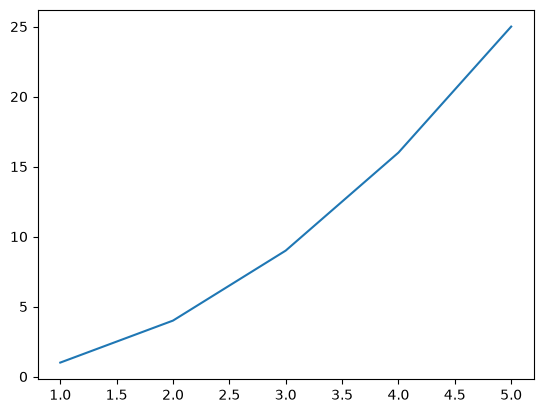

In [16]:
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y)
plt.show()

Matplotlib doesn't add labels for you. Set them with `plt.xlabel`, `plt.ylabel`, and `plt.title`.

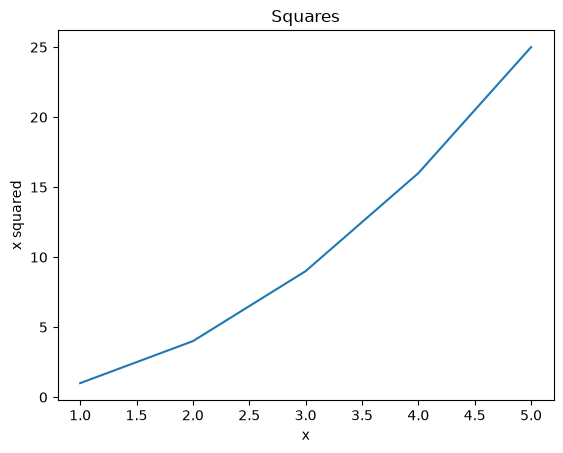

In [17]:
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('x squared')
plt.title('Squares')
plt.show()

It works with our DataFrame columns too. Here's a **scatter plot** with `plt.scatter`:

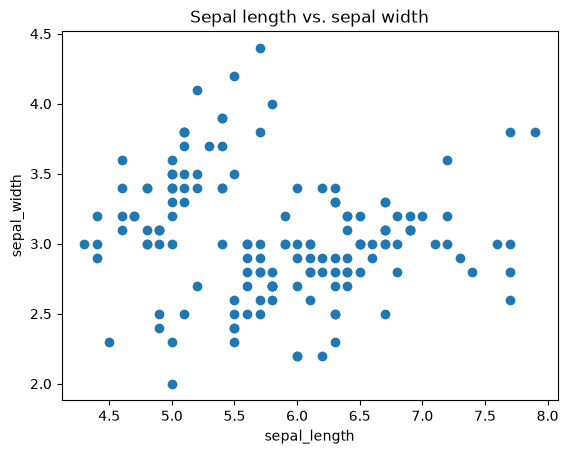

In [18]:
plt.scatter(dataset['sepal_length'], dataset['sepal_width'])
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.title('Sepal length vs. sepal width')
plt.show()

Notice we had to pull out each column and add the labels ourselves, and we can't easily color by class. Seaborn takes care of a lot of that for us.

# Seaborn

**Seaborn** is another plotting library, and it works directly with pandas DataFrames. Plotly makes interactive charts; Seaborn makes static images that look good by default and take very little code. Just pass in your DataFrame as `data=`, then name the columns you want for `x`, `y`, and `hue` (Seaborn's word for `color`).

Seaborn draws on top of `matplotlib`, so we import both. `plt.show()` displays the plot.

In [29]:
import seaborn as sns

sns.set_theme()   # applies Seaborn's default look

A **scatter plot**, colored by class:

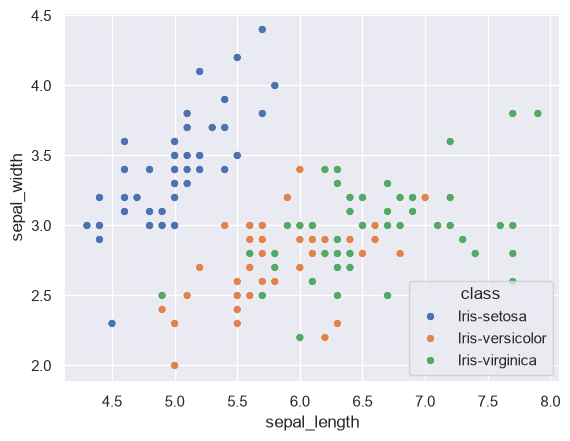

In [30]:
sns.scatterplot(data=dataset, x='sepal_length', y='sepal_width', hue='class')
plt.show()

A **histogram**. Setting `kde=True` adds a smooth density line:

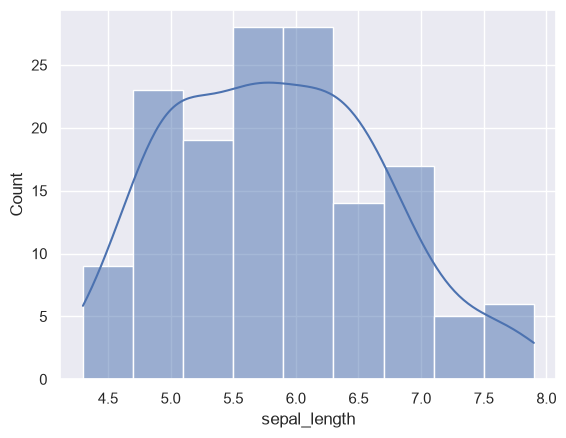

In [31]:
sns.histplot(data=dataset, x='sepal_length', kde=True)
plt.show()

A **box plot** of petal length for each class:

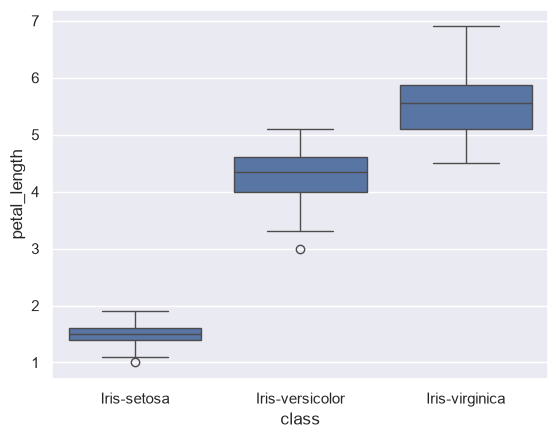

In [32]:
sns.boxplot(data=dataset, x='class', y='petal_length')
plt.show()

A **violin plot** of petal length for each class:

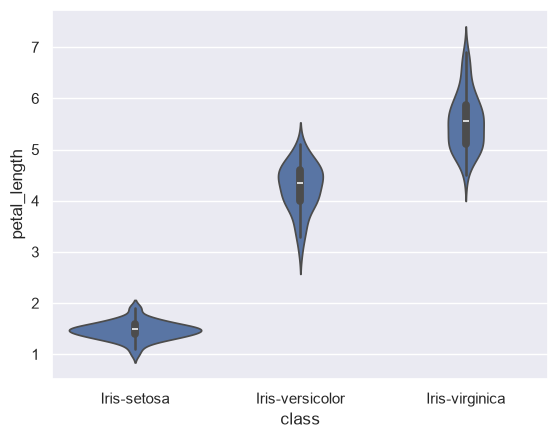

In [23]:
sns.violinplot(data=dataset, x='class', y='petal_length')
plt.show()

One thing Seaborn does especially well: `pairplot` plots **every pair of numeric columns** against each other, colored by class.

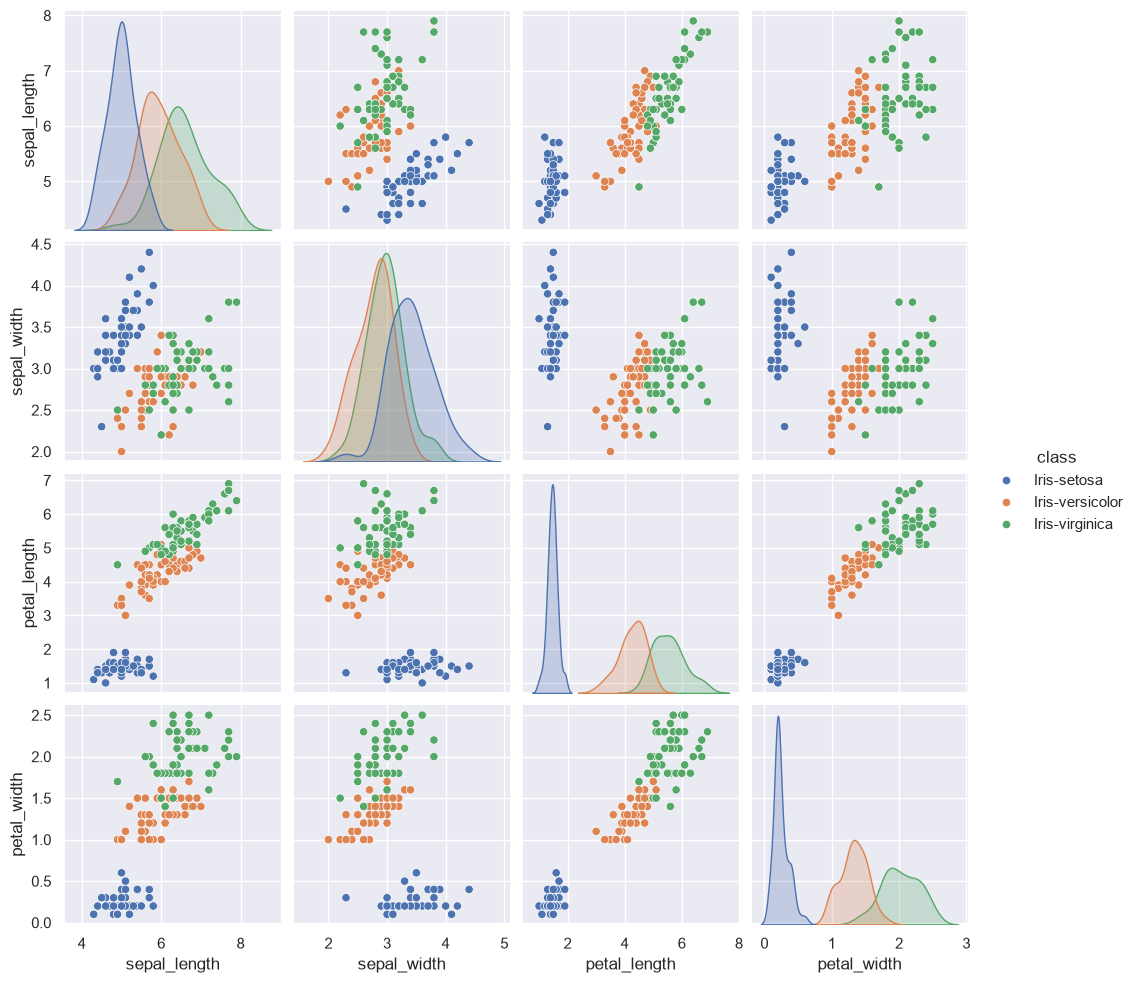

In [24]:
sns.pairplot(dataset, hue='class')
plt.show()

### Plotly vs. Seaborn

| Plot | Plotly | Seaborn |
|---|---|---|
| scatter | `px.scatter(..., color=)` | `sns.scatterplot(..., hue=)` |
| histogram | `px.histogram` | `sns.histplot` |
| box | `px.box` | `sns.boxplot` |
| violin | `px.violin` | `sns.violinplot` |

**Final Exercise**

In [25]:
"""

Use skills you've learned to set up sepal width, length, and petal width, length
into four graphs, separated by class.

HINT: Use the function px.box

"""


"\n\nUse skills you've learned to set up sepal width, length, and petal width, length\ninto four graphs, separated by class.\n\nHINT: Use the function px.box\n\n"